c:\Users\黃\.conda\envs\py310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


模型準確率 = 1.0

分類報告：
              precision    recall  f1-score   support

          正常       1.00      1.00      1.00         3
          異常       1.00      1.00      1.00         1
          警告       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5

測試案例 1: (70, 100, 5)
預測結果: 正常
詳細資訊: ML 預測完成，設備狀態為：正常
----------------------------------------
測試案例 2: (85, 120, 11)
預測結果: 警告
詳細資訊: ML 預測完成，設備狀態為：警告
----------------------------------------
測試案例 3: (110, 160, 18)
預測結果: 異常
詳細資訊: ML 預測完成，設備狀態為：異常
----------------------------------------
測試案例 4: (-1, 100, 5)
預測結果: 資料錯誤
詳細資訊: temperature 不可小於 0
----------------------------------------
測試案例 5: ('hot', 120, 10)
預測結果: 資料錯誤
詳細資訊: temperature 資料型態錯誤
----------------------------------------

模型類別順序: ['正常' '異常' '警告']

正在繪製類別：正常 的 SHAP 圖


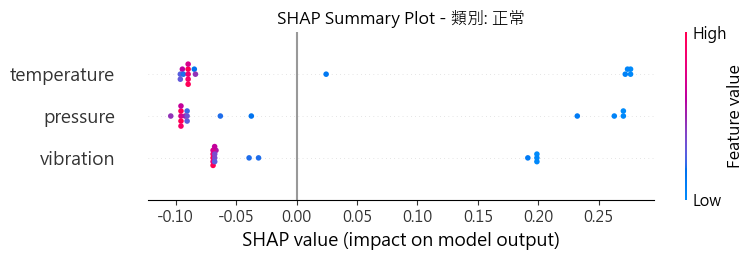


正在繪製類別：異常 的 SHAP 圖


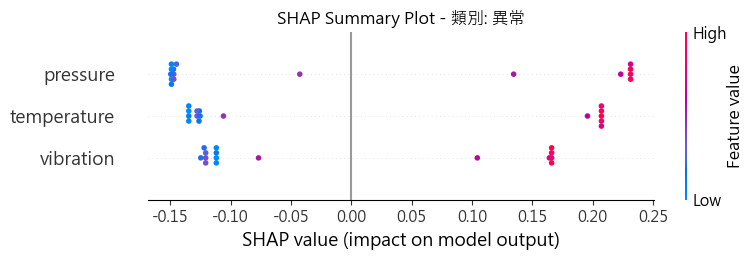


正在繪製類別：警告 的 SHAP 圖


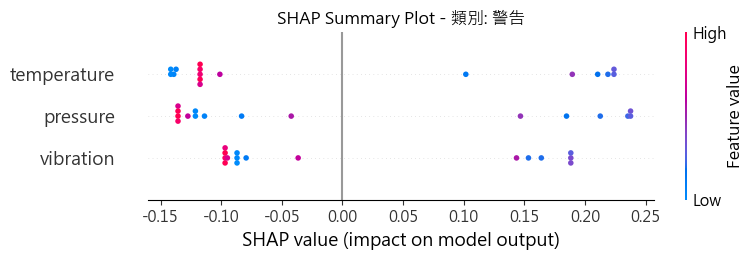


單筆測試資料：
   temperature  pressure  vibration
0           70       100          5
模型預測結果： 正常


c:\Users\黃\.conda\envs\py310\lib\site-packages\shap\plots\_waterfall.py:638: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
c:\Users\黃\.conda\envs\py310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


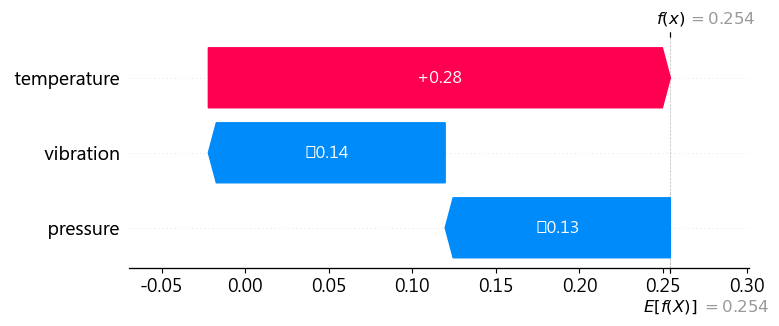

In [1]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # Windows 使用微軟正黑體
plt.rcParams['axes.unicode_minus'] = False # 確保負號正常顯示

# RandomForestClassifier-決策樹

# 1. 資料驗證函式
# temperature 溫度, pressure 壓力, vibration 振動
def validate_sensor_data(temperature, pressure, vibration):
    if not isinstance(temperature, (int, float)):
        return False, "temperature 資料型態錯誤"
    if not isinstance(pressure, (int, float)):
        return False, "pressure 資料型態錯誤"
    if not isinstance(vibration, (int, float)):
        return False, "vibration 資料型態錯誤"

    if temperature < 0:
        return False, "temperature 不可小於 0"
    if pressure < 0:
        return False, "pressure 不可小於 0"
    if vibration < 0:
        return False, "vibration 不可小於 0"

    return True, "資料驗證成功"


# 2. 建立訓練資料
data = pd.DataFrame([
    [70, 100, 5, "正常"],
    [72, 102, 6, "正常"],
    [75, 105, 7, "正常"],
    [78, 110, 8, "正常"],
    [80, 115, 9, "正常"],

    [82, 118, 10, "警告"],
    [85, 120, 11, "警告"],
    [88, 125, 12, "警告"],
    [90, 130, 13, "警告"],
    [95, 135, 14, "警告"],

    [101, 140, 15, "異常"],
    [105, 145, 16, "異常"],
    [110, 150, 17, "異常"],
    [115, 160, 18, "異常"],
    [120, 170, 20, "異常"],

    [76, 108, 7, "正常"],
    [84, 122, 10, "警告"],
    [108, 155, 17, "異常"],
    [79, 112, 8, "正常"],
    [89, 128, 12, "警告"],
    [112, 165, 19, "異常"]
], columns=["temperature", "pressure", "vibration", "label"])


# 3. 切分特徵與標籤
X = data[["temperature", "pressure", "vibration"]]
y = data["label"]


# 4. 切分訓練集與測試集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 5. 建立並訓練模型
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)


# 6. 評估模型
y_pred = model.predict(X_test)

print("模型準確率 =", accuracy_score(y_test, y_pred))
print("\n分類報告：")
print(classification_report(y_test, y_pred))


# 7. 預測函式
def predict_equipment_status_ml(temperature, pressure, vibration):
    # 先做資料驗證
    is_valid, message = validate_sensor_data(temperature, pressure, vibration)
    if not is_valid:
        return {
            "result": "資料錯誤",
            "message": message
        }

    # 建立輸入資料
    input_df = pd.DataFrame(
        [[temperature, pressure, vibration]],
        columns=["temperature", "pressure", "vibration"]
    )

    # 模型預測
    prediction = model.predict(input_df)[0]

    return {
        "result": prediction,
        "message": f"ML 預測完成，設備狀態為：{prediction}"
    }


# 8. 測試新資料
samples = [
    (70, 100, 5),
    (85, 120, 11),
    (110, 160, 18),
    (-1, 100, 5),
    ("hot", 120, 10)
]

for idx, sample in enumerate(samples, start=1):
    temperature, pressure, vibration = sample
    result = predict_equipment_status_ml(temperature, pressure, vibration)

    print(f"測試案例 {idx}: {sample}")
    print("預測結果:", result["result"])
    print("詳細資訊:", result["message"])
    print("-" * 40)


# 9. 加入 SHAP 解釋


# 建立 explainer
explainer = shap.TreeExplainer(model)

# 取得 SHAP values
shap_values = explainer.shap_values(X_train)

print("\n模型類別順序:", model.classes_)

# ---- 全域特徵重要度 ----
# 多分類時，shap_values 通常會依類別拆開
# 這裡逐類別畫 summary plot
for i, class_name in enumerate(model.classes_):
    print(f"\n正在繪製類別：{class_name} 的 SHAP 圖")
    shap.summary_plot(
       shap_values[:, :, i],       # 第 i 類的 shap 值
        X_train,
        show=False
    )
    plt.title(f"SHAP Summary Plot - 類別: {class_name}")
    plt.tight_layout()
    plt.show()


# ---- 單筆資料解釋 ----
sample_idx = 0
single_sample = X_test.iloc[[sample_idx]]
pred_class = model.predict(single_sample)[0]

print("\n單筆測試資料：")
print(single_sample)
print("模型預測結果：", pred_class)

# 找到預測類別在 classes_ 裡的索引
pred_class_index = list(model.classes_).index(pred_class)

# 該筆資料的 SHAP 值
single_shap_values = explainer.shap_values(single_sample)

# waterfall plot 需要單一類別、單一樣本
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[pred_class_index],
    single_shap_values[pred_class_index][0],
    feature_names=single_sample.columns,
    features=single_sample.iloc[0]
)

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

# 訓練資料
train_data = pd.DataFrame([
    [70, 100, 5, "正常"],
    [75, 105, 6, "正常"],
    [82, 110, 8, "警告"],
    [85, 125, 9, "警告"],
    [90, 130, 11, "警告"],
    [105, 100, 5, "異常"],
    [110, 160, 18, "異常"],
    [95, 155, 12, "異常"],
    [78, 118, 10, "正常"],
    [88, 121, 10, "警告"],
    [101, 149, 9, "異常"],
    [79, 119, 9, "正常"]
], columns=["temperature", "pressure", "vibration", "label"])

X_train = train_data[["temperature", "pressure", "vibration"]].values.astype("float32")
y_train_text = train_data["label"].values

# 標籤編碼
le = LabelEncoder()
y_train = le.fit_transform(y_train_text)

# 建立模型
dl_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu", input_shape=(3,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

dl_model.compile(optimizer="adam",
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

# 訓練
dl_model.fit(X_train, y_train, epochs=100, verbose=0)

# 預測函式
def predict_by_dl(temperature, pressure, vibration):
    x = np.array([[temperature, pressure, vibration]], dtype="float32")
    pred = dl_model.predict(x, verbose=0)
    pred_label = np.argmax(pred, axis=1)[0]
    return le.inverse_transform([pred_label])[0]

# 測試
print(predict_by_dl(85, 130, 12))
print(predict_by_dl(70, 100, 5))
print(predict_by_dl(110, 160, 18))

警告
警告
正常
